In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [7]:
df = pd.read_csv('Employee Attrition Prediction Dataset.csv') 

TARGET_VARIABLE = 'Attrition_Enc'
RANDOM_STATE = 42

In [8]:
X = df.drop(TARGET_VARIABLE, axis=1)
y = df[TARGET_VARIABLE]

# Validation Method: Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [9]:
# --- STEP 2: Hyperparameter Tuning (Creating Model Varieties) ---

param_grid = {
    'C': [0.01, 0.1, 1, 10],            # Regularization strength
    'penalty': ['l1', 'l2']             # Regularization type
}

In [10]:
# Initialize the model: 'liblinear' supports both L1 and L2.
# class_weight='balanced' helps handle potential class imbalance.
logreg = LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000)

# Validation Method: k-fold Cross-Validation with GridSearchCV
grid_search = GridSearchCV(
    logreg, 
    param_grid, 
    cv=5,                 # 5-fold cross-validation
    scoring='f1',         # Optimize for F1-Score
    n_jobs=-1             
)

grid_search.fit(X_train, y_train) 

best_logreg_model = grid_search.best_estimator_

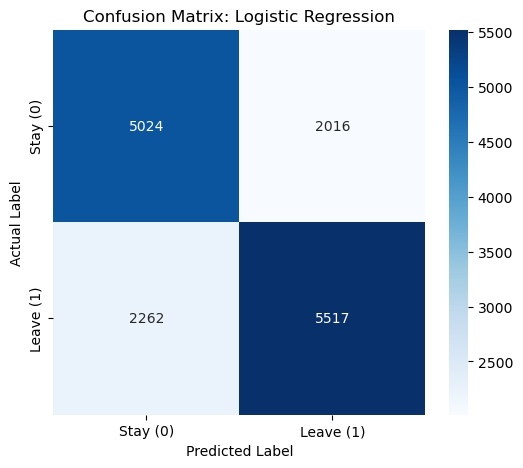

In [14]:
# --- STEP 3: Evaluation (Metrics) ---

y_pred = best_logreg_model.predict(X_test)
y_pred_proba = best_logreg_model.predict_proba(X_test)[:, 1]

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stay (0)', 'Leave (1)'], 
            yticklabels=['Stay (0)', 'Leave (1)'])
plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_logreg.png') 
# Close plot to prevent display artifacts

In [17]:
# Comparison of all feature coefficients
coefficients = best_logreg_model.coef_[0]
feature_names = X_train.columns
coef_df = pd.DataFrame({
    'Feature': feature_names,  # Retype this line fully
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n--- Feature Importance (Coefficients) ---")
print(coef_df)


--- Feature Importance (Coefficients) ---
                  Feature  Coefficient
9        Job Level_Senior     1.763227
6         Remote Work_Enc     1.413645
8   Marital Status_Single    -1.363467
4   Work-Life Balance_Enc     0.474648
3      Distance from Home    -0.241729
5  Company Reputation_Enc     0.230527
7  Marital Status_Married     0.164586
1        Years at Company     0.144625
0                     Age     0.067928
2          Monthly Income     0.032506
